 # Exploration of the HD model of sound responses of thalamic HD cells (14-Parameter DoVM Architecture)

In vivo bins: 500, range -1497.0..1497.0 ms
FR range raw:      18.7..190.1 Hz
FR range smoothed: 22.5..91.9 Hz

Running differential_evolution with 13-Parameter DoVM (Workers Unleashed!)...


c:\Users\FloHofmann\github\workbench\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 815.9746981176914
differential_evolution step 2: f(x)= 815.9746981176914
differential_evolution step 3: f(x)= 815.9746981176914
differential_evolution step 4: f(x)= 621.1991796217807
differential_evolution step 5: f(x)= 618.273447502662
differential_evolution step 6: f(x)= 548.8318846948669
differential_evolution step 7: f(x)= 548.8318846948669
differential_evolution step 8: f(x)= 548.8318846948669
differential_evolution step 9: f(x)= 548.8318846948669
differential_evolution step 10: f(x)= 548.8318846948669
differential_evolution step 11: f(x)= 548.8318846948669
differential_evolution step 12: f(x)= 548.8318846948669
differential_evolution step 13: f(x)= 548.8318846948669
differential_evolution step 14: f(x)= 497.5388484989092
differential_evolution step 15: f(x)= 497.5388484989092
differential_evolution step 16: f(x)= 497.5388484989092
differential_evolution step 17: f(x)= 497.5388484989092
differential_evolution step 18: f(x)= 497.5388484989092
di

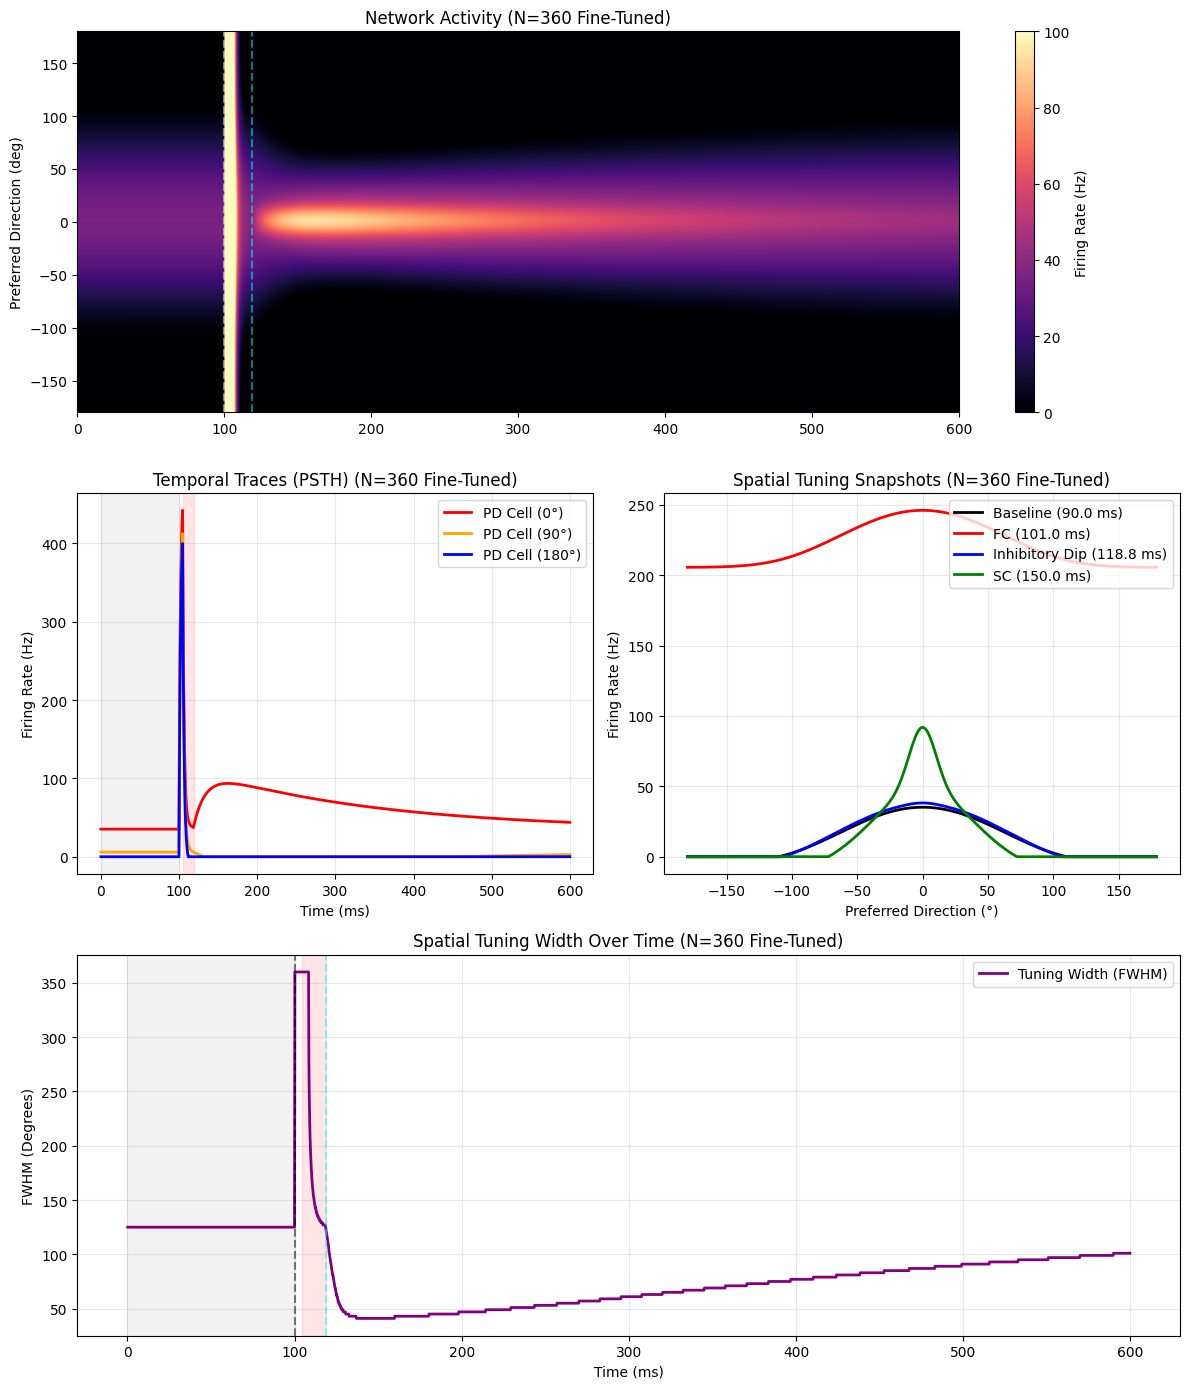


   N=360 in vivo fit assessment   
  Pure MSE (Unweighted): 45.52 Hz^2
  R-Squared (R^2):       0.9305
  Verdict: EXCELLENT fit.



NameError: name 'matched_times' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
import sqlite3
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import differential_evolution, minimize
from scipy.interpolate import interp1d

from workbench.data.preprocess import combTableCreate, expand_dict_columns

# ==========================================
# 1. Constants & Pre-computations
# ==========================================
N = 100
THETA = np.linspace(-np.pi, np.pi, N, endpoint=False)
SIGMA_PHASIC = 10

DT = 0.2
T_BURN_IN = -300
T_END = 600
TIME = np.arange(T_BURN_IN, T_END, DT)

T_STIM = 100

# Creation of the Connectivity Matrix and their assigned preferred directions
COS_D_THETA = np.cos(np.angle(np.exp(1j * (THETA[:, None] - THETA[None, :]))))
IDX_0 = np.argmin(np.abs(THETA))
IDX_180 = np.argmin(np.abs(THETA - np.pi))


# ==========================================
# 2. Function Definitions
# ==========================================
def run_model_temporal(
    I_baseline,
    A_fast,
    A_phasic,
    tau_decay,
    J1,
    KAPPA,
    J0,
    U_floor,
    T_phasic,
    tau_neural,
    fc_stim_duration,
):
    """Run CANN with DoVM connectivity and fully dynamic temporal/spatial parameters."""
    W_local = (J1 * np.exp(KAPPA * (COS_D_THETA - 1.0)) - J0) / N

    u = 40.0 * np.maximum(0, np.cos(THETA))
    r = np.maximum(0, u)
    rates = np.zeros((len(TIME), N))

    sigma_phasic_rad = np.deg2rad(SIGMA_PHASIC)

    for step, t in enumerate(TIME):
        I_ext = np.ones(N) * I_baseline

        # Now uses the optimized fc_stim_duration parameter
        if T_STIM <= t < (T_STIM + fc_stim_duration):
            I_ext += A_fast

        elif t >= T_phasic:
            decay = np.exp(-(t - T_phasic) / tau_decay)
            I_ext += A_phasic * decay * np.exp(-0.5 * (THETA / sigma_phasic_rad) ** 2)

        u += (-u + W_local @ r + I_ext) * (DT / tau_neural)
        u = np.maximum(U_floor, u)

        r = np.maximum(0, u)
        rates[step, :] = r

    mask = TIME >= 0
    return TIME[mask] - T_STIM, rates[mask, :]


def plot_model_full(
    I_baseline,
    A_fast,
    A_phasic,
    tau_decay,
    J1,
    KAPPA,
    J0,
    U_floor,
    T_phasic,
    tau_neural,
    fc_stim_duration,
    title_suffix="",
):
    """Run CANN with given params and produce the full diagnostic plot."""
    t_rel, rates_plot = run_model_temporal(
        I_baseline,
        A_fast,
        A_phasic,
        tau_decay,
        J1,
        KAPPA,
        J0,
        U_floor,
        T_phasic,
        tau_neural,
        fc_stim_duration,
    )
    time_plot = t_rel + T_STIM

    idx_0 = np.argmin(np.abs(THETA))
    idx_90 = np.argmin(np.abs(THETA - np.pi / 2))
    idx_180 = np.argmin(np.abs(THETA - np.pi))

    dynamic_times_to_plot = [90, 101, T_phasic, 150]

    fwhm = np.zeros(len(time_plot))
    for i in range(len(time_plot)):
        profile = rates_plot[i, :]
        peak = np.max(profile)
        if peak > 1.0:
            half_max = peak / 2.0
            active_bins = np.sum(profile >= half_max)
            fwhm[i] = active_bins * (360.0 / N)
        else:
            fwhm[i] = 0.0

    fig = plt.figure(figsize=(12, 14))
    gs = fig.add_gridspec(3, 2)

    ax1 = fig.add_subplot(gs[0, :])
    im = ax1.imshow(
        rates_plot.T,
        aspect="auto",
        origin="lower",
        extent=[0, T_END, -180, 180],
        cmap="magma",
        vmin=0,
        vmax=100,
    )
    ax1.set_ylabel("Preferred Direction (deg)")
    ax1.set_title(f"Network Activity{title_suffix}")
    ax1.axvline(T_STIM, color="white", linestyle="--", alpha=0.5)
    ax1.axvline(T_phasic, color="cyan", linestyle="--", alpha=0.5)
    fig.colorbar(im, ax=ax1, label="Firing Rate (Hz)")

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(time_plot, rates_plot[:, idx_0], label="PD Cell (0°)", color="red", lw=2)
    ax2.plot(
        time_plot, rates_plot[:, idx_90], label="PD Cell (90°)", color="orange", lw=2
    )
    ax2.plot(
        time_plot, rates_plot[:, idx_180], label="PD Cell (180°)", color="blue", lw=2
    )
    ax2.axvspan(0, T_STIM, color="gray", alpha=0.1)
    ax2.axvspan(T_STIM + fc_stim_duration, T_phasic, color="red", alpha=0.1)
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("Firing Rate (Hz)")
    ax2.set_title(f"Temporal Traces (PSTH){title_suffix}")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    snap_colors = ["black", "red", "blue", "green"]
    base_names = ["Baseline", "FC", "Inhibitory Dip", "SC"]
    snap_labels = [
        f"{name} ({t:.1f} ms)" for name, t in zip(base_names, dynamic_times_to_plot)
    ]
    for t_target, color, label in zip(dynamic_times_to_plot, snap_colors, snap_labels):
        ax3.plot(
            np.rad2deg(THETA),
            rates_plot[int(t_target / DT), :],
            label=label,
            color=color,
            lw=2,
        )
    ax3.set_xlabel("Preferred Direction (°)")
    ax3.set_ylabel("Firing Rate (Hz)")
    ax3.set_title(f"Spatial Tuning Snapshots{title_suffix}")
    ax3.legend(loc="upper right")
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[2, :])
    ax4.plot(time_plot, fwhm, color="purple", lw=2, label="Tuning Width (FWHM)")
    ax4.axvspan(0, T_STIM, color="gray", alpha=0.1)
    ax4.axvspan(T_STIM + fc_stim_duration, T_phasic, color="red", alpha=0.1)
    ax4.axvline(T_STIM, color="black", linestyle="--", alpha=0.5)
    ax4.axvline(T_phasic, color="cyan", linestyle="--", alpha=0.5)
    ax4.set_xlabel("Time (ms)")
    ax4.set_ylabel("FWHM (Degrees)")
    ax4.set_title(f"Spatial Tuning Width Over Time{title_suffix}")
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ==========================================
# 3. Data Loading
# ==========================================
conn = sqlite3.connect(
    r"\\172.25.250.112\burgalossi\lab share\Data\Florian\Recordings_FH.db"
)
sql = """
SELECT * FROM Recordings WHERE (Animal_Id, Cell_Id) IN (
SELECT Animal_Id, Cell_Id FROM Recordings WHERE Condition IN ("Baseline", "soso") GROUP BY Animal_Id, Cell_Id
HAVING COUNT(DISTINCT Condition) >= 2)
AND Condition IN ("Baseline","soso") AND use = 1 AND Folders_generated = 1
"""
datatable = pd.read_sql_query(sql, conn)
conn.close()

try:
    comb_table = pl.read_parquet(
        Path(
            r"\\172.25.250.112\burgalossi\lab share\Data\Florian\comb_tables\soso_comb.parquet"
        )
    )
except Exception:
    print("comb_table doesn't exist, creating...")
    comb_table = combTableCreate(datatable)
    comb_df = pd.DataFrame(comb_table)
    comb_df = expand_dict_columns(
        comb_df, dict_columns=["pupil_psth", "whisk_psth", "eye_psth"], flatten_2d=False
    )
    comb_table = pl.from_dataframe(comb_df)
    conditions = comb_table["Condition"].unique().to_list()
    comb_a = comb_table.filter(pl.col("Condition") == conditions[0]).drop("Condition")
    comb_b = comb_table.filter(pl.col("Condition") == conditions[1]).drop("Condition")
    comb_joined = comb_a.join(comb_b, on=["Animal_Id", "Cell_Id"], how="inner")
    comb_joined = comb_joined[
        [s.name for s in comb_joined if not (s.null_count() == comb_joined.height)]
    ]
    comb_table = comb_joined.rename(lambda c: c[:-6] if c.endswith("_right") else c)
    comb_table.write_parquet(
        r"\\172.25.250.112\burgalossi\lab share\Data\Florian\comb_tables\soso_comb.parquet",
        use_pyarrow=True,
    )

comb_table = comb_table.filter(pl.col("n_stims") > 40)

speaker_position = {"a": 93, "w": 178, "e": 272, "r": 356}
speakers = ["a", "w", "e", "r"]

half_window = 1500
time_bin = 0.006
nbins = int(np.round(half_window / (time_bin * 1000)))
raster_edges = np.linspace(-half_window, half_window, nbins * 2 + 1)

bins_plot = np.concatenate(
    [
        [raster_edges[0]],
        np.median(np.vstack([raster_edges[:-1], raster_edges[1:]]), axis=0),
    ]
)
bins_plot = bins_plot[1:]

raster_times = comb_table["RasterTimes"]
raster_rows = comb_table["RasterRows"]
stim_keys = list(raster_times[0].keys())
stim_key_to_idx = {k: i for i, k in enumerate(stim_keys)}
speaker_idx = [stim_key_to_idx[k] for k in speakers]

new_rate = np.zeros((len(raster_times), len(raster_edges) - 1, len(stim_keys)))
for i in range(len(raster_times)):
    for j in stim_keys:
        if len(raster_times[i][j]) != 0:
            counts, _ = np.histogram(raster_times[i][j], bins=raster_edges)
            new_rate[i, :, stim_key_to_idx[j]] = counts / (
                np.max(raster_rows[i][j]) * time_bin
            )

new_rate = new_rate[:, :, speaker_idx]

preferred = np.array(comb_table["HDAngle"])
speaker_angles = np.array(list(speaker_position.values()))
diff = preferred[:, None] - speaker_angles[None, :]
wrapped = (diff + 180) % 360 - 180
idx_sorted = np.argsort(np.abs(wrapped), axis=1)
new_rate_sort = np.take_along_axis(new_rate, idx_sorted[:, None, :], axis=2)

mean_vivo_rate = new_rate_sort[:, :, 0].mean(axis=0)

SMOOTH_SIGMA = 3
mean_vivo_smooth = gaussian_filter1d(mean_vivo_rate.astype(float), sigma=SMOOTH_SIGMA)
WIN_LO, WIN_HI = -50, 300


# ==========================================
# 4. Objective Function
# ==========================================
def loss_temporal(params):
    (
        I_baseline,
        A_fast,
        A_phasic,
        tau_decay,
        J1,
        KAPPA,
        J0,
        U_floor,
        T_phasic,
        tau_neural,
        fc_stim_duration,
        t_delay,
    ) = params

    t_model_rel, rates = run_model_temporal(
        I_baseline, A_fast, A_phasic, tau_decay, J1, KAPPA, 
        J0, U_floor, T_phasic, tau_neural, fc_stim_duration
    )

    if np.any(np.isnan(rates)) or np.any(np.isinf(rates)):
        return 1e10

    pd_trace = rates[:, IDX_0]
    anti_pd_trace = rates[:, IDX_180]

    t_vivo_rel = bins_plot.astype(float) - t_delay
    vivo_mask = (t_vivo_rel >= WIN_LO) & (t_vivo_rel <= WIN_HI)
    model_mask = (t_model_rel >= WIN_LO) & (t_model_rel <= WIN_HI)

    if vivo_mask.sum() < 3 or model_mask.sum() < 3:
        return 1e10

    interp_fn = interp1d(
        t_model_rel[model_mask],
        pd_trace[model_mask],
        bounds_error=False,
        fill_value="extrapolate",
    )

    matched_times = t_vivo_rel[vivo_mask]
    model_at_vivo = interp_fn(matched_times)

    # --- THE HYBRID TARGET ---
    # Use RAW data for the startle spike, SMOOTH data for the decay tail
    hybrid_target = np.zeros_like(matched_times)
    
    # Let's say the transient chaos ends around 20ms post-stimulus
    early_mask = matched_times <= 20.0 
    late_mask = matched_times > 20.0
    
    hybrid_target[early_mask] = mean_vivo_rate[vivo_mask][early_mask]
    hybrid_target[late_mask] = mean_vivo_smooth[vivo_mask][late_mask]

    # Penalty 1: Shape Error (Against the Hybrid Target)
    raw_errors = (model_at_vivo - hybrid_target) ** 2
    weights = np.ones_like(raw_errors)
    
    # Tell the optimizer to care a little bit more about hitting the spike
    weights[early_mask] = 5.0 
    
    weighted_mse = np.average(raw_errors, weights=weights)

    # Penalty 2: Baseline Background (Keep tails silent before stimulus)
    baseline_mask = (t_model_rel >= WIN_LO) & (t_model_rel < 0)
    anti_pd_baseline_rate = np.mean(anti_pd_trace[baseline_mask])
    background_error = (anti_pd_baseline_rate - 0.0) ** 2

    total_loss = weighted_mse + (background_error * 50.0)

    if np.isnan(total_loss) or np.isinf(total_loss):
        return 1e10

    return float(total_loss)


if __name__ == "__main__":
    print(f"In vivo bins: {len(bins_plot)}, range {bins_plot[0]}..{bins_plot[-1]} ms")
    print(
        f"FR range raw:      {mean_vivo_rate.min():.1f}..{mean_vivo_rate.max():.1f} Hz"
    )
    print(
        f"FR range smoothed: {mean_vivo_smooth.min():.1f}..{mean_vivo_smooth.max():.1f} Hz"
    )

    # --- Run Optimization with 14 Parameters ---
    OPT_BOUNDS = [
        (5, 60),  # 0. I_baseline
        (200, 3000),  # 1. A_fast
        (10, 300),  # 2. A_phasic
        (20, 500),  # 3. tau_decay
        (1.0, 30.0),  # 4. J1
        (2.0, 20.0),  # 5. Kappa
        (0.1, 20.0),  # 6. J0
        (-40, -1),  # 8. U_FLOOR
        (102, 150),  # 9. T_PHASIC
        (10, 50.0),  # 11. TAU_NEURAL (ms)
        (1.0, 5.0),  # 12. FC_STIM_DURATION (ms) - NEW PARAMETER
        (0, 60),  # 13. t_delay
    ]

    print(
        "\nRunning differential_evolution with 13-Parameter DoVM (Workers Unleashed!)..."
    )
    opt_result = differential_evolution(
        loss_temporal,
        OPT_BOUNDS,
        seed=42,
        maxiter=1000,
        popsize=30,
        tol=1e-5,
        mutation=(0.8, 1.9),
        recombination=0.5,
        polish=True,
        disp=True,
        workers=-1,
    )

    (
        I_opt,
        Af_opt,
        Ap_opt,
        tau_opt,
        J1_opt,
        KAPPA_opt,
        J0_opt,
        U_floor_opt,
        T_phasic_opt,
        tau_neu_opt,
        fc_dur_opt,
        td_opt,
    ) = opt_result.x

    print(
        f"\n--- N=100 Optimization complete (Weighted Loss = {opt_result.fun:.2f}) ---"
    )
    print(f"  I_BASELINE       = {I_opt:.2f}")
    print(f"  A_FAST           = {Af_opt:.2f}")
    print(f"  FC_STIM_DURATION = {fc_dur_opt:.2f} ms")
    print(f"  A_PHASIC         = {Ap_opt:.2f}")
    print(f"  TAU_PHASIC_DECAY = {tau_opt:.2f} ms")
    print(f"  J_EXC (Amp)      = {J1_opt:.2f}")
    print(f"  K_EXC (Sharp)    = {KAPPA_opt:.2f}")
    print(f"  J_INH (Amp)      = {J0_opt:.2f}")
    print(f"  U_FLOOR          = {U_floor_opt:.2f}")
    print(
        f"  T_PHASIC (Onset) = {T_phasic_opt:.2f} ms (Delay = {T_phasic_opt - 100:.2f} ms)"
    )
    print(f"  TAU_NEURAL       = {tau_neu_opt:.2f} ms")
    print(f"  t_delay          = {td_opt:.2f} ms")

    # ==========================================
    # 6. HIGH-RESOLUTION REFINEMENT (N=360)
    # ==========================================
    print("\n" + "=" * 42)
    print("   UPSCALING TO N=360 FOR FINE-TUNING   ")
    print("=" * 42)

    N = 360
    THETA = np.linspace(-np.pi, np.pi, N, endpoint=False)
    COS_D_THETA = np.cos(np.angle(np.exp(1j * (THETA[:, None] - THETA[None, :]))))
    IDX_0 = np.argmin(np.abs(THETA))
    IDX_180 = np.argmin(np.abs(THETA - np.pi))

    best_100N_params = opt_result.x

    print("\nRefining N=360 model using Local Gradient Descent (L-BFGS-B)...")
    opt_result_360 = minimize(
        loss_temporal,
        x0=best_100N_params,
        bounds=OPT_BOUNDS,
        method="L-BFGS-B",
        options={"disp": True, "maxiter": 100},
    )

    (
        I_h,
        Af_h,
        Ap_h,
        tau_h,
        J1_h,
        KAPPA_h,
        J0_h,
        U_floor_h,
        T_phasic_h,
        tau_neu_h,
        fc_dur_h,
        td_h,
    ) = opt_result_360.x

    print(
        f"\n--- N=360 Optimization complete (Weighted Loss = {opt_result_360.fun:.2f}) ---"
    )
    print(f"  I_BASELINE       = {I_h:.2f}")
    print(f"  A_FAST           = {Af_h:.2f}")
    print(f"  FC_STIM_DURATION = {fc_dur_h:.2f} ms")
    print(f"  A_PHASIC         = {Ap_h:.2f}")
    print(f"  TAU_PHASIC_DECAY = {tau_h:.2f} ms")
    print(f"  J_EXC (Amp)      = {J1_h:.2f}")
    print(f"  K_EXC (Sharp)    = {KAPPA_h:.2f}")
    print(f"  J_INH (Amp)      = {J0_h:.2f}")
    print(f"  U_FLOOR          = {U_floor_h:.2f}")
    print(f"  T_PHASIC (Onset) = {T_phasic_h:.2f} ms")
    print(f"  TAU_NEURAL       = {tau_neu_h:.2f} ms")
    print(f"  t_delay          = {td_h:.2f} ms")

    # 4. Generate High-Resolution Visualizations
    plot_model_full(
        I_h,
        Af_h,
        Ap_h,
        tau_h,
        J1_h,
        KAPPA_h,
        J0_h,
        U_floor_h,
        T_phasic_h,
        tau_neu_h,
        fc_dur_h,
        title_suffix=" (N=360 Fine-Tuned)",
    )

    # 5. Final High-Resolution Biological Fit Assessment
    t_model_rel_h, rates_opt_h = run_model_temporal(
        I_h,
        Af_h,
        Ap_h,
        tau_h,
        J1_h,
        KAPPA_h,
        J0_h,
        U_floor_h,
        T_phasic_h,
        tau_neu_h,
        fc_dur_h,
    )

    t_vivo_rel_h = bins_plot.astype(float) - td_h
    vivo_mask_h = (t_vivo_rel_h >= WIN_LO) & (t_vivo_rel_h <= WIN_HI)
    model_mask_h = (t_model_rel_h >= WIN_LO) & (t_model_rel_h <= WIN_HI)

    interp_fn_h = interp1d(
        t_model_rel_h[model_mask_h],
        rates_opt_h[model_mask_h, IDX_0],
        bounds_error=False,
        fill_value="extrapolate",
    )
    model_at_vivo_h = interp_fn_h(t_vivo_rel_h[vivo_mask_h])
    biology_h = mean_vivo_rate[vivo_mask_h]

    pure_mse_h = np.mean((model_at_vivo_h - biology_h) ** 2)

    ss_res_h = np.sum((biology_h - model_at_vivo_h) ** 2)
    ss_tot_h = np.sum((biology_h - np.mean(biology_h)) ** 2)
    r_squared_h = 1.0 - (ss_res_h / ss_tot_h)

    print("\n==========================================")
    print("   N=360 in vivo fit assessment   ")

    print(f"  Pure MSE (Unweighted): {pure_mse_h:.2f} Hz^2")
    print(f"  R-Squared (R^2):       {r_squared_h:.4f}")
    if r_squared_h > 0.90:
        print("  Verdict: EXCELLENT fit.")
    elif r_squared_h > 0.70:
        print("  Verdict: GOOD fit.")
    else:
        print("  Verdict: POOR fit.")
    print("==========================================\n")


    # ==========================================
    # VISUALIZE THE DOWNSAMPLED FIT (The "Camera's" View)
    # ==========================================
    plt.figure(figsize=(10, 5))
    
    # Plot the raw 6ms biological data
    plt.plot(matched_times, mean_vivo_rate[vivo_mask], label="In Vivo Data (6ms bins)", color='black', alpha=0.5, lw=2)
    
    # Plot the smoothed biological tail (just for reference)
    plt.plot(matched_times, mean_vivo_smooth[vivo_mask], label="Smoothed In Vivo", color='gray', linestyle=':', lw=2)

    # Plot the model AS SEEN BY THE OPTIMIZER (Downsampled)
    plt.plot(matched_times, model_at_vivo_h, label="Model (Downsampled to 6ms)", color='red', lw=2)
    
    plt.axvline(0, color='black', linestyle='--', alpha=0.3)
    plt.xlim(-50, 300)
    plt.xlabel("Time relative to stimulus (ms)")
    plt.ylabel("Firing Rate (Hz)")
    plt.title("The Optimizer's Perspective: Downsampled Model vs Biology")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

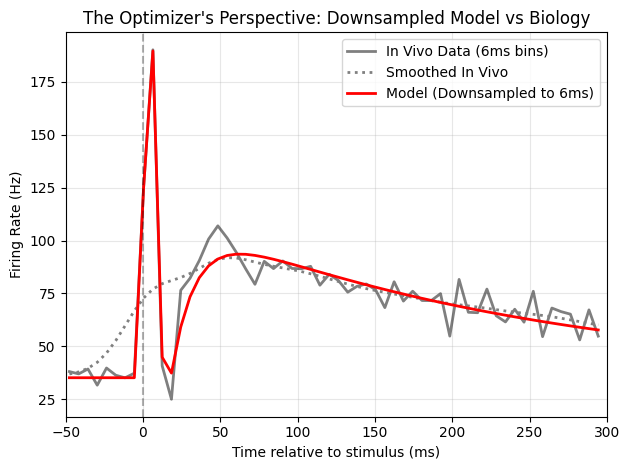

In [ ]:
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_rate[vivo_mask_h], label="In Vivo Data (6ms bins)", color='black', alpha=0.5, lw=2)

# Plot the smoothed biological tail (just for reference)
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_smooth[vivo_mask_h], label="Smoothed In Vivo", color='gray', linestyle=':', lw=2)

# Plot the model AS SEEN BY THE OPTIMIZER (Downsampled)
plt.plot(t_vivo_rel_h[vivo_mask_h], model_at_vivo_h, label="Model (Downsampled to 6ms)", color='red', lw=2)

plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.xlim(-50, 300)
plt.xlabel("Time relative to stimulus (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.title("The Optimizer's Perspective: Downsampled Model vs Biology")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


   N=360 in vivo fit assessment   
  Pure MSE (Unweighted): 45.52 Hz^2
  R-Squared (R^2):       0.9305
  Verdict: EXCELLENT fit.



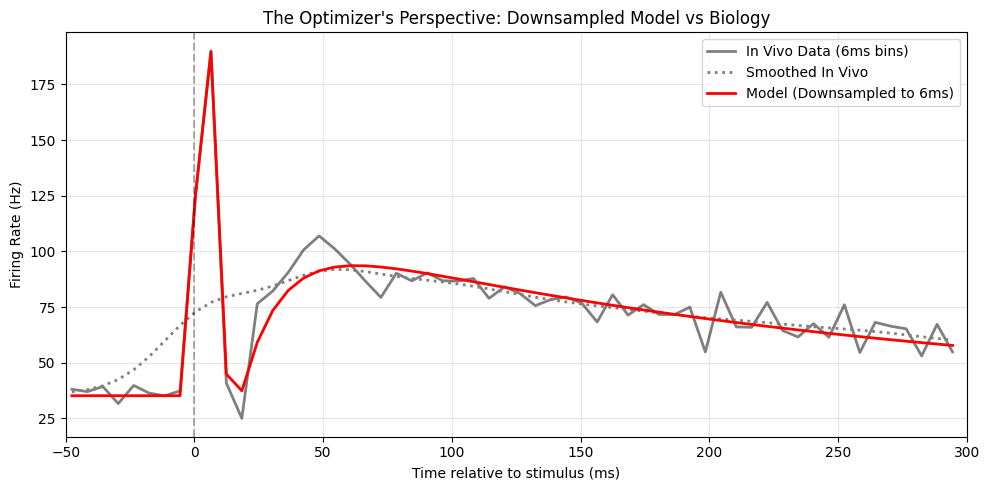

In [ ]:
t_model_rel_h, rates_opt_h = run_model_temporal(
    I_h,
    Af_h,
    Ap_h,
    tau_h,
    J1_h,
    KAPPA_h,
    J0_h,
    U_floor_h,
    T_phasic_h,
    tau_neu_h,
    fc_dur_h,
)

t_vivo_rel_h = bins_plot.astype(float) - td_h
vivo_mask_h = (t_vivo_rel_h >= WIN_LO) & (t_vivo_rel_h <= WIN_HI)
model_mask_h = (t_model_rel_h >= WIN_LO) & (t_model_rel_h <= WIN_HI)

interp_fn_h = interp1d(
    t_model_rel_h[model_mask_h],
    rates_opt_h[model_mask_h, IDX_0],
    bounds_error=False,
    fill_value="extrapolate",
)
model_at_vivo_h = interp_fn_h(t_vivo_rel_h[vivo_mask_h])
biology_h = mean_vivo_rate[vivo_mask_h]

pure_mse_h = np.mean((model_at_vivo_h - biology_h) ** 2)

ss_res_h = np.sum((biology_h - model_at_vivo_h) ** 2)
ss_tot_h = np.sum((biology_h - np.mean(biology_h)) ** 2)
r_squared_h = 1.0 - (ss_res_h / ss_tot_h)

print("\n==========================================")
print("   N=360 in vivo fit assessment   ")

print(f"  Pure MSE (Unweighted): {pure_mse_h:.2f} Hz^2")
print(f"  R-Squared (R^2):       {r_squared_h:.4f}")
if r_squared_h > 0.90:
    print("  Verdict: EXCELLENT fit.")
elif r_squared_h > 0.70:
    print("  Verdict: GOOD fit.")
else:
    print("  Verdict: POOR fit.")
print("==========================================\n")


# ==========================================
# VISUALIZE THE DOWNSAMPLED FIT (The "Camera's" View)
# ==========================================
plt.figure(figsize=(10, 5))

# Plot the raw 6ms biological data
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_rate[vivo_mask_h], label="In Vivo Data (6ms bins)", color='black', alpha=0.5, lw=2)

# Plot the smoothed biological tail (just for reference)
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_smooth[vivo_mask_h], label="Smoothed In Vivo", color='gray', linestyle=':', lw=2)

# Plot the model AS SEEN BY THE OPTIMIZER (Downsampled)
plt.plot(t_vivo_rel_h[vivo_mask_h], model_at_vivo_h, label="Model (Downsampled to 6ms)", color='red', lw=2)

plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.xlim(-50, 300)
plt.xlabel("Time relative to stimulus (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.title("The Optimizer's Perspective: Downsampled Model vs Biology")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

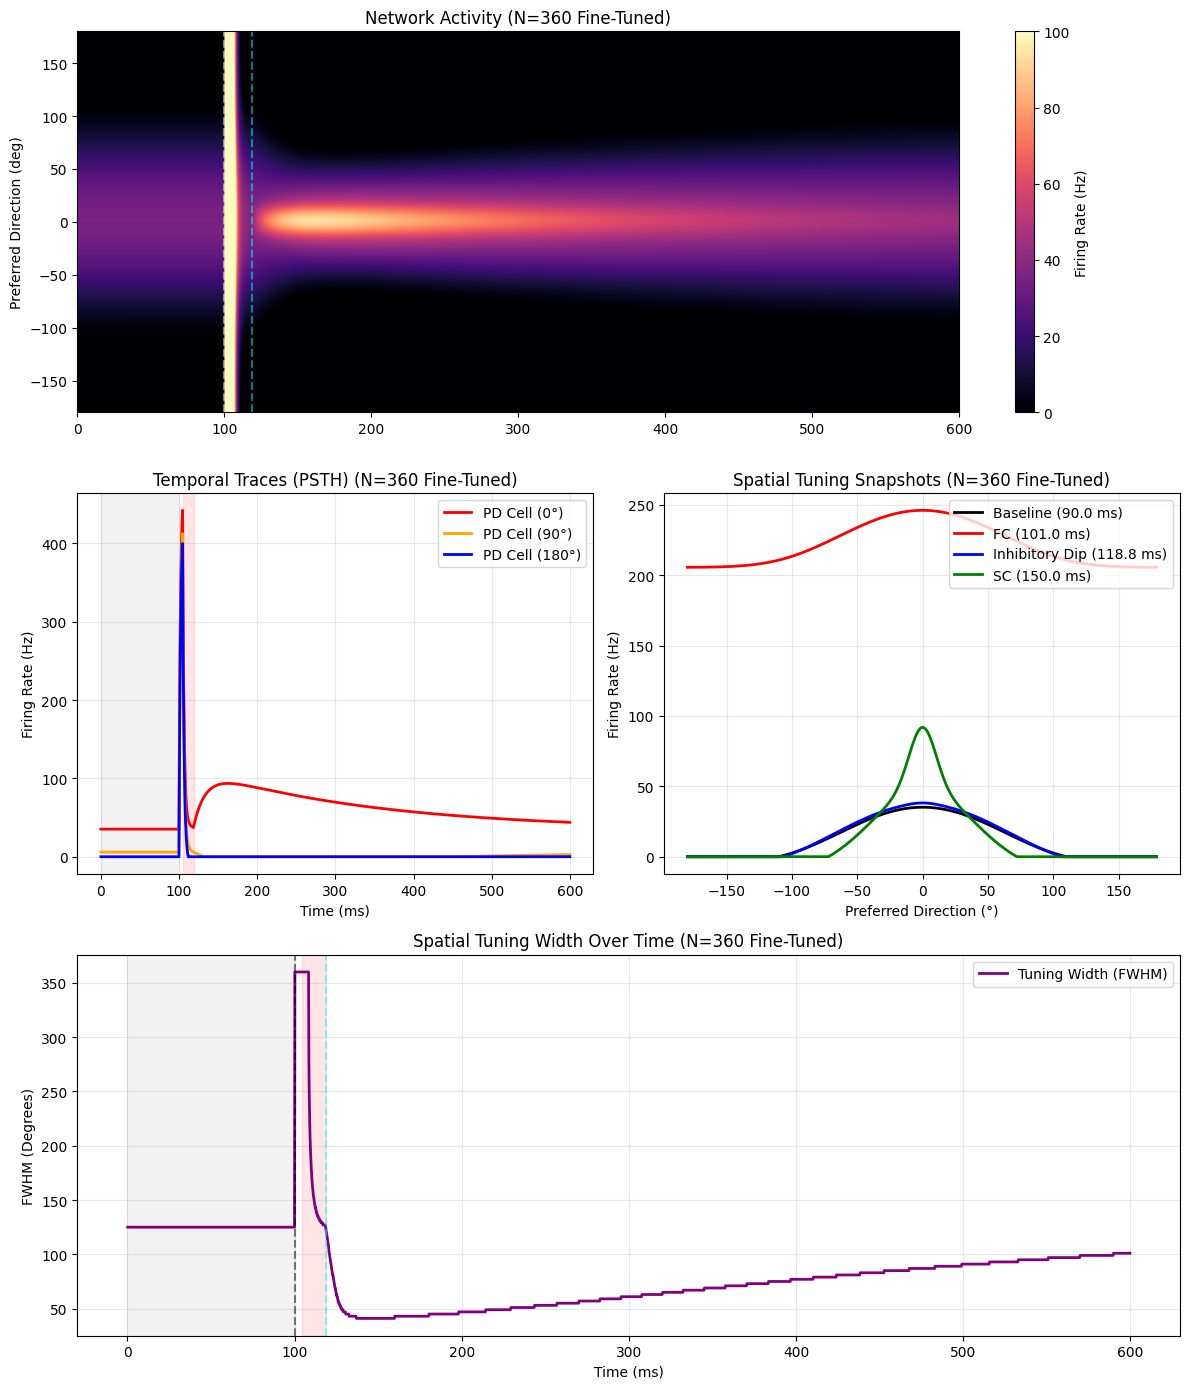


   N=360 in vivo fit assessment   
  Pure MSE (Unweighted): 45.52 Hz^2
  R-Squared (R^2):       0.9305
  Verdict: EXCELLENT fit.



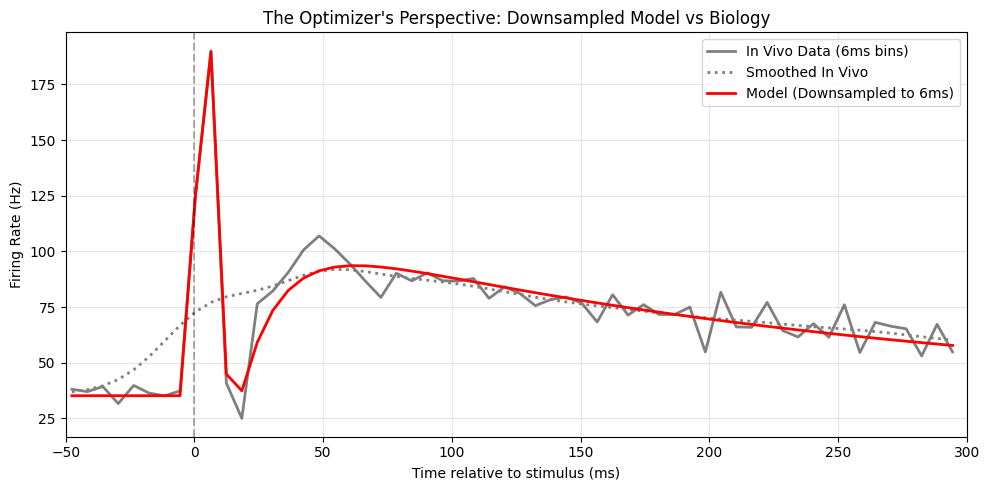

In [ ]:
# 4. Generate High-Resolution Visualizations
plot_model_full(
    I_h,
    Af_h,
    Ap_h,
    tau_h,
    J1_h,
    KAPPA_h,
    J0_h,
    U_floor_h,
    T_phasic_h,
    tau_neu_h,
    fc_dur_h,
    title_suffix=" (N=360 Fine-Tuned)",
)

# 5. Final High-Resolution Biological Fit Assessment
t_model_rel_h, rates_opt_h = run_model_temporal(
    I_h,
    Af_h,
    Ap_h,
    tau_h,
    J1_h,
    KAPPA_h,
    J0_h,
    U_floor_h,
    T_phasic_h,
    tau_neu_h,
    fc_dur_h,
)

t_vivo_rel_h = bins_plot.astype(float) - td_h
vivo_mask_h = (t_vivo_rel_h >= WIN_LO) & (t_vivo_rel_h <= WIN_HI)
model_mask_h = (t_model_rel_h >= WIN_LO) & (t_model_rel_h <= WIN_HI)

interp_fn_h = interp1d(
    t_model_rel_h[model_mask_h],
    rates_opt_h[model_mask_h, IDX_0],
    bounds_error=False,
    fill_value="extrapolate",
)
model_at_vivo_h = interp_fn_h(t_vivo_rel_h[vivo_mask_h])
biology_h = mean_vivo_rate[vivo_mask_h]

pure_mse_h = np.mean((model_at_vivo_h - biology_h) ** 2)

ss_res_h = np.sum((biology_h - model_at_vivo_h) ** 2)
ss_tot_h = np.sum((biology_h - np.mean(biology_h)) ** 2)
r_squared_h = 1.0 - (ss_res_h / ss_tot_h)

print("\n==========================================")
print("   N=360 in vivo fit assessment   ")

print(f"  Pure MSE (Unweighted): {pure_mse_h:.2f} Hz^2")
print(f"  R-Squared (R^2):       {r_squared_h:.4f}")
if r_squared_h > 0.90:
    print("  Verdict: EXCELLENT fit.")
elif r_squared_h > 0.70:
    print("  Verdict: GOOD fit.")
else:
    print("  Verdict: POOR fit.")
print("==========================================\n")


# ==========================================
# VISUALIZE THE DOWNSAMPLED FIT (The "Camera's" View)
# ==========================================
plt.figure(figsize=(10, 5))

# Plot the raw 6ms biological data
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_rate[vivo_mask_h], label="In Vivo Data (6ms bins)", color='black', alpha=0.5, lw=2)

# Plot the smoothed biological tail (just for reference)
plt.plot(t_vivo_rel_h[vivo_mask_h], mean_vivo_smooth[vivo_mask_h], label="Smoothed In Vivo", color='gray', linestyle=':', lw=2)

# Plot the model AS SEEN BY THE OPTIMIZER (Downsampled)
plt.plot(t_vivo_rel_h[vivo_mask_h], model_at_vivo_h, label="Model (Downsampled to 6ms)", color='red', lw=2)

plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.xlim(-50, 300)
plt.xlabel("Time relative to stimulus (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.title("The Optimizer's Perspective: Downsampled Model vs Biology")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()